In [16]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import FEATURES, PROCESSED_DIR, RANDOM_STATE
from src.extraction import load_raw_data
from src.preprocessing import (make_clean)

## Feature Story 1 : EDA

In [2]:
df = load_raw_data()
print(df.shape)          # dimensions
print(df.dtypes)         # types
df.head()

(8950, 8)
CUST_ID                       str
BALANCE                   float64
PURCHASES                 float64
ONEOFF_PURCHASES          float64
INSTALLMENTS_PURCHASES    float64
CASH_ADVANCE              float64
CREDIT_LIMIT              float64
PAYMENTS                  float64
dtype: object


,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,C10001,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084
1,C10002,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597
2,C10003,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742
3,C10004,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000
4,C10005,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763


### # Valeurs manquantes (nombre + %), triées par ordre décroissant

In [10]:
manquants = df.isna().sum().to_frame("nb_manquants")
manquants["pct"] = (manquants["nb_manquants"] / len(df) * 100).round(2)
manquants = manquants.sort_values("nb_manquants", ascending=False)
display(manquants)

print("Doublons :", df.duplicated().sum())
df[FEATURES].describe()

,nb_manquants,pct
CREDIT_LIMIT,1,0.01
CUST_ID,0,0.00
PURCHASES,0,0.00
BALANCE,0,0.00
ONEOFF_PURCHASES,0,0.00
INSTALLMENTS_PURCHASES,0,0.00
CASH_ADVANCE,0,0.00
PAYMENTS,0,0.00


Doublons : 0


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,1564.474828,1003.204834,592.437371,411.067645,978.871112,4494.449450,1733.143852
std,2081.531879,2136.634782,1659.887917,904.338115,2097.163877,3638.815725,2895.063757
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,0.000000,1600.000000,383.276166
50%,873.385231,361.280000,38.000000,89.000000,0.000000,3000.000000,856.901546
75%,2054.140036,1110.130000,577.405000,468.637500,1113.821139,6500.000000,1901.134317
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360


### # Histogrammes + KDE, skewness dans le titre

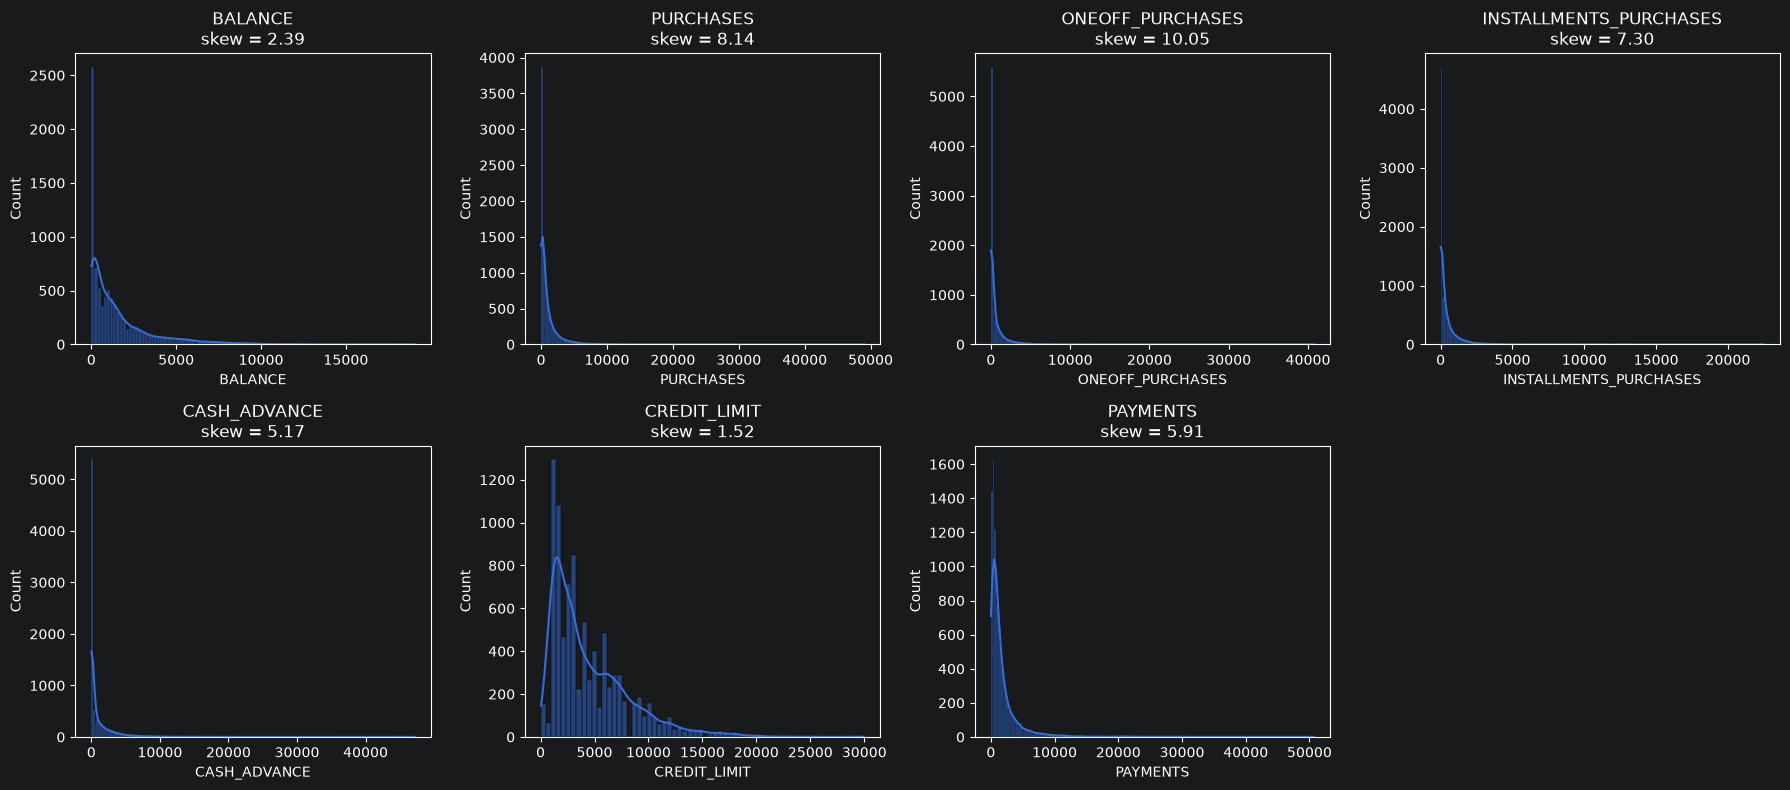

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, FEATURES):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"{col}\nskew = {df[col].skew():.2f}")
for ax in axes[len(FEATURES):]:
    ax.axis("off")                      # cache la case vide (7 variables / 8 cases)
plt.tight_layout(); plt.show()

### Heatmap des corrélations

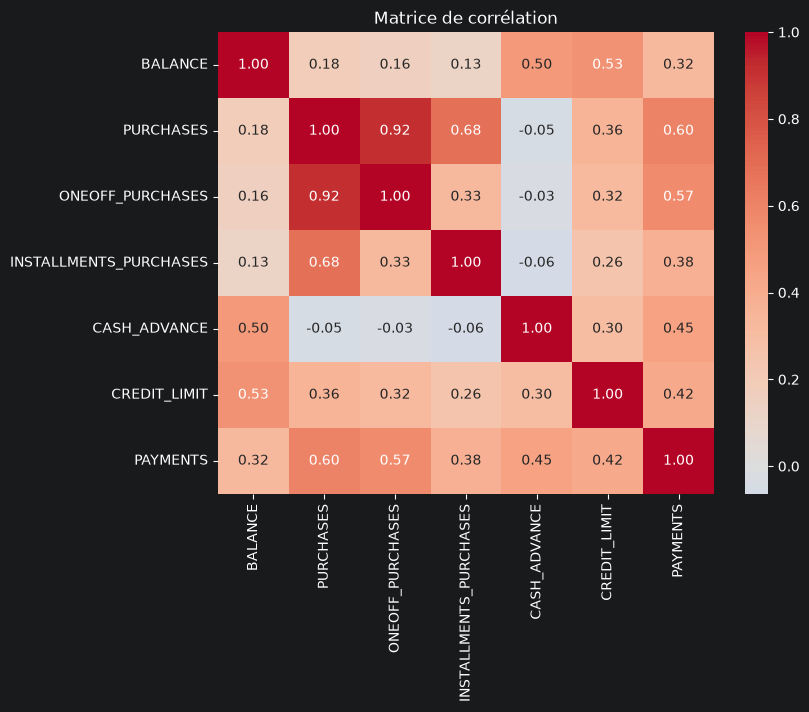

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation"); plt.show()

### Outliers

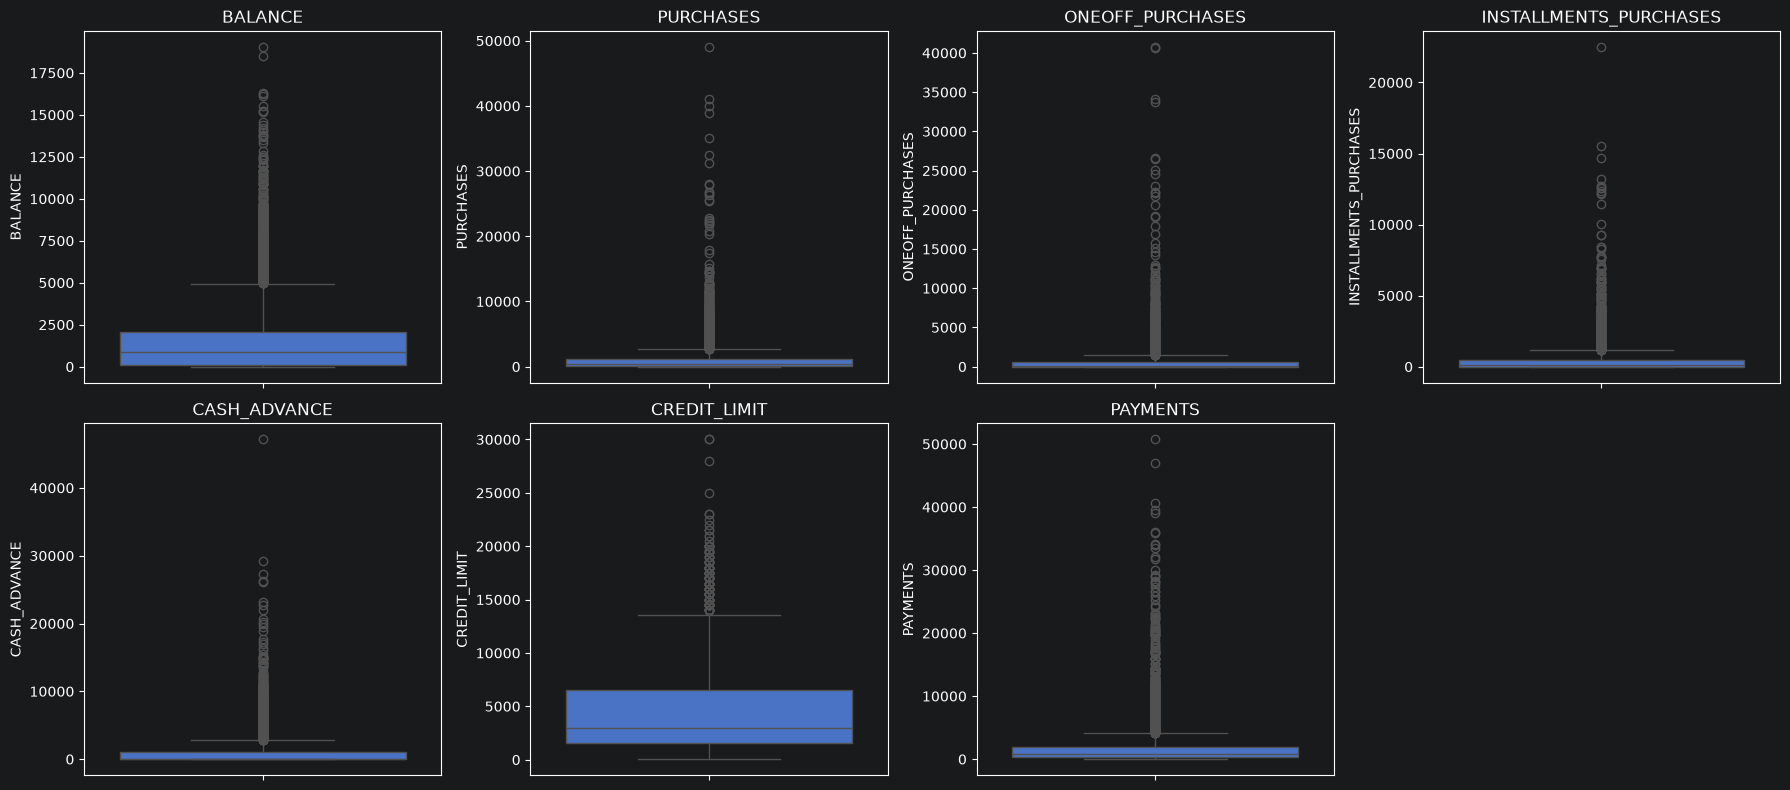

,variable,nb_outliers,pct
0,BALANCE,695,7.8
1,PURCHASES,808,9.0
2,ONEOFF_PURCHASES,1013,11.3
3,INSTALLMENTS_PURCHASES,867,9.7
4,CASH_ADVANCE,1030,11.5
5,CREDIT_LIMIT,248,2.8
6,PAYMENTS,808,9.0


In [15]:
# Boxplots (outliers)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, FEATURES):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
for ax in axes[len(FEATURES):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

# Nombre d'outliers
rows = []
for col in FEATURES:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    rows.append({"variable": col, "nb_outliers": n, "pct": round(n / len(df) * 100, 1)})
pd.DataFrame(rows)

## Feature Story 2 : Prétraitement

### Nettoyage minimal + sauvegarde AVANT toute transformation 

In [18]:
df_clean = make_clean(df)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(PROCESSED_DIR / "df_clean.csv", index=False)
print(df_clean.shape)

(8949, 7)
